# GGO Image Processing Pipeline Validation Notebook

This notebook validates each step of the classical image-processing pipeline for GGO detection using CT-RATE CT volumes and ReXGroundingCT `2c` ground-truth masks.

Use this notebook before changing `pipeline.py` so you can identify exactly which stage is failing: GT loading, lung masking, HU thresholding, adaptive thresholding, component filtering, or visualization.

## 1. Imports and paths

In [12]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# Change this if your notebook is not inside image-processing/
PROJECT_DIR = r"D:\\My\\Projects\\fyp-3d-ct\\image-processing"
DATASET_JSON = r"D:\\My\\Projects\\fyp-3d-ct\\data\\rexgrounding-ct\\dataset_img_processing.json"

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from pipeline import (
    load_nifti_file,
    get_voxel_spacing,
    apply_hu_window,
    get_lung_mask,
    detect_ggo,
    min_volume_to_voxels,
    spacing_to_sigma_voxels,
    get_case_adaptive_threshold,
    load_ggo_gt_mask,
    compute_dice,
    compute_iou,
    compute_sensitivity_precision,
)

print('Imports complete')

Imports complete


## 2. Select one case

In [13]:
SPLIT = 'train'
CASE_INDEX = 0

with open(DATASET_JSON, 'r', encoding='utf-8') as f:
    dataset = json.load(f)

samples = dataset[SPLIT]
sample = samples[CASE_INDEX]

print('Total samples in split:', len(samples))
print('Selected name:', sample['name'])
print('CT path:', sample['ct_path'])
print('SEG path:', sample['seg_path'])
print('GGO channels:', sample['ggo_channels'])

print('\nFindings:')
for ch in sample['ggo_channels']:
    print(f"Channel {ch}: {sample['findings'][str(ch)]}")

Total samples in split: 18
Selected name: train_67_a_2.nii.gz
CT path: D:\My\Projects\fyp-3d-ct\data\data_volumes\train_67\train_67_a\train_67_a_2.nii.gz
SEG path: D:\My\Projects\fyp-3d-ct\data\segmentations\train_67_a_2.nii.gz
GGO channels: [0]

Findings:
Channel 0: Peripherally located patchy ground glass opacities in bilateral lungs with associated vascular enlargement


## 3. Load CT and ReXGroundingCT GT mask

In [28]:
ct_data, ct_affine, ct_header = load_nifti_file(sample['ct_path'])
gt_mask, gt_affine, gt_header = load_nifti_file(sample['seg_path'])

ct_spacing = get_voxel_spacing(ct_header)
gt_spacing = get_voxel_spacing(gt_header)

print('CT shape:', ct_data.shape)
print('GT shape:', gt_mask.shape)

print('CT spacing:', ct_spacing)
print('GT spacing:', gt_spacing)

print('CT affine:\n', ct_affine)
print('GT affine:\n', gt_affine)

print('GT voxels:', int(gt_mask.sum()))

# Shape check
if ct_data.shape != gt_mask.shape:
    raise ValueError(
        f'Shape mismatch: CT {ct_data.shape}, GT {gt_mask.shape}'
    )

# Spacing check
if not np.allclose(ct_spacing, gt_spacing, atol=1e-5):
    raise ValueError(
        f'Spacing mismatch: CT {ct_spacing}, GT {gt_spacing}'
    )

# Affine/orientation check
if not np.allclose(ct_affine, gt_affine, atol=1e-5):
    raise ValueError('CT and GT affines do not match')

CT shape: (512, 512, 496)
GT shape: (1, 512, 512, 496)
CT spacing: (0.71484375, 0.71484375, 0.75)
GT spacing: (1.0, 1.0, 1.0)
CT affine:
 [[ -0.71484375   0.           0.         201.37269592]
 [  0.          -0.71484375   0.          -5.85301971]
 [  0.           0.           0.75       281.25      ]
 [  0.           0.           0.           1.        ]]
GT affine:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
GT voxels: 38563


ValueError: Shape mismatch: CT (512, 512, 496), GT (1, 512, 512, 496)

## 4. Utility functions for visualization

In [15]:
def get_gt_slices(mask):
    slices = np.where(mask.sum(axis=(0, 1)) > 0)[0]
    return slices


def show_overlay(ct, gt=None, pred=None, lung=None, slice_idx=None, title=''):
    if slice_idx is None:
        if gt is not None and gt.sum() > 0:
            slices = get_gt_slices(gt)
            slice_idx = int(slices[len(slices) // 2])
        else:
            slice_idx = ct.shape[2] // 2

    ct_windowed = apply_hu_window(ct)
    ct_slice = ct_windowed[:, :, slice_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(ct_slice.T, cmap='gray', origin='lower')

    if lung is not None:
        lung_slice = lung[:, :, slice_idx]
        plt.imshow(np.ma.masked_where(lung_slice.T == 0, lung_slice.T), cmap='Blues', alpha=0.25, origin='lower')

    if gt is not None:
        gt_slice = gt[:, :, slice_idx]
        plt.imshow(np.ma.masked_where(gt_slice.T == 0, gt_slice.T), cmap='Greens', alpha=0.45, origin='lower')

    if pred is not None:
        pred_slice = pred[:, :, slice_idx]
        plt.imshow(np.ma.masked_where(pred_slice.T == 0, pred_slice.T), cmap='Reds', alpha=0.40, origin='lower')

    plt.title(f'{title} | Slice {slice_idx}')
    plt.axis('off')
    plt.show()


def show_four_panel(ct, gt=None, pred=None, lung=None, slice_idx=None):
    if slice_idx is None:
        if gt is not None and gt.sum() > 0:
            slices = get_gt_slices(gt)
            slice_idx = int(slices[len(slices) // 2])
        else:
            slice_idx = ct.shape[2] // 2

    ct_windowed = apply_hu_window(ct)
    ct_slice = ct_windowed[:, :, slice_idx]

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.ravel()

    axes[0].imshow(ct_slice.T, cmap='gray', origin='lower')
    axes[0].set_title('CT')

    axes[1].imshow(ct_slice.T, cmap='gray', origin='lower')
    if lung is not None:
        lung_slice = lung[:, :, slice_idx]
        axes[1].imshow(np.ma.masked_where(lung_slice.T == 0, lung_slice.T), cmap='Blues', alpha=0.35, origin='lower')
    axes[1].set_title('Lung Mask')

    axes[2].imshow(ct_slice.T, cmap='gray', origin='lower')
    if gt is not None:
        gt_slice = gt[:, :, slice_idx]
        axes[2].imshow(np.ma.masked_where(gt_slice.T == 0, gt_slice.T), cmap='Greens', alpha=0.45, origin='lower')
    axes[2].set_title('GT GGO')

    axes[3].imshow(ct_slice.T, cmap='gray', origin='lower')
    if pred is not None:
        pred_slice = pred[:, :, slice_idx]
        axes[3].imshow(np.ma.masked_where(pred_slice.T == 0, pred_slice.T), cmap='Reds', alpha=0.40, origin='lower')
    if gt is not None:
        gt_slice = gt[:, :, slice_idx]
        axes[3].imshow(np.ma.masked_where(gt_slice.T == 0, gt_slice.T), cmap='Greens', alpha=0.30, origin='lower')
    axes[3].set_title('Prediction Red + GT Green')

    for ax in axes:
        ax.axis('off')

    plt.suptitle(f'Slice {slice_idx}')
    plt.show()

## 5. Validate GT slices

Number of slices with GT: 31
First GT slice: 249
Middle GT slice: 264
Last GT slice: 299


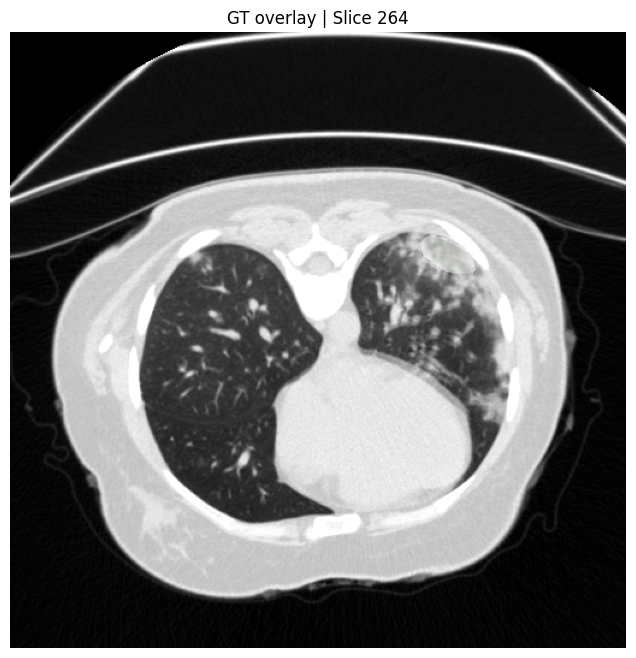

In [16]:
gt_slices = get_gt_slices(gt_mask)

print('Number of slices with GT:', len(gt_slices))
if len(gt_slices) > 0:
    print('First GT slice:', int(gt_slices[0]))
    print('Middle GT slice:', int(gt_slices[len(gt_slices)//2]))
    print('Last GT slice:', int(gt_slices[-1]))
    show_overlay(ct_data, gt=gt_mask, slice_idx=int(gt_slices[len(gt_slices)//2]), title='GT overlay')
else:
    print('No GT voxels found.')

## 6. Validate lung segmentation

Lung voxels: 5705682
Lung / CT ratio: 0.043881954685334235
GT inside lung mask ratio: 0.48813280878474774


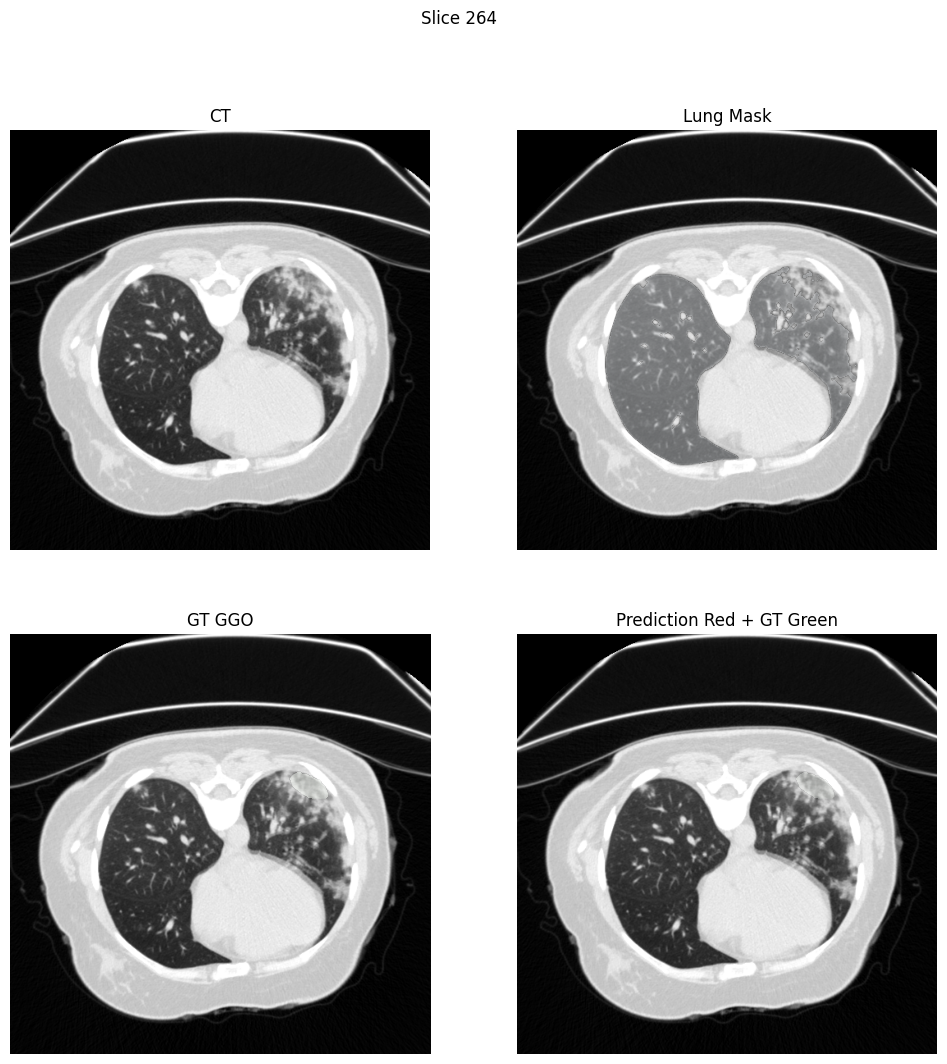

In [17]:
LUNG_THRESHOLD = -400

lung_mask = get_lung_mask(ct_data, lung_threshold=LUNG_THRESHOLD)

print('Lung voxels:', int(lung_mask.sum()))
print('Lung / CT ratio:', lung_mask.sum() / ct_data.size)

if gt_mask.sum() > 0:
    gt_inside_lung = (gt_mask & lung_mask).sum() / gt_mask.sum()
    print('GT inside lung mask ratio:', gt_inside_lung)

show_four_panel(ct_data, gt=gt_mask, lung=lung_mask)

## 7. Create expanded analysis lung mask

This helps because strict lung masks may exclude dense abnormal regions. Detection can be done inside an expanded lung-analysis mask rather than only inside the strict low-HU lung mask.

Analysis mask voxels: 6290654
Analysis / CT ratio: 0.04838092865482453
GT inside analysis mask ratio: 0.6787428126756301


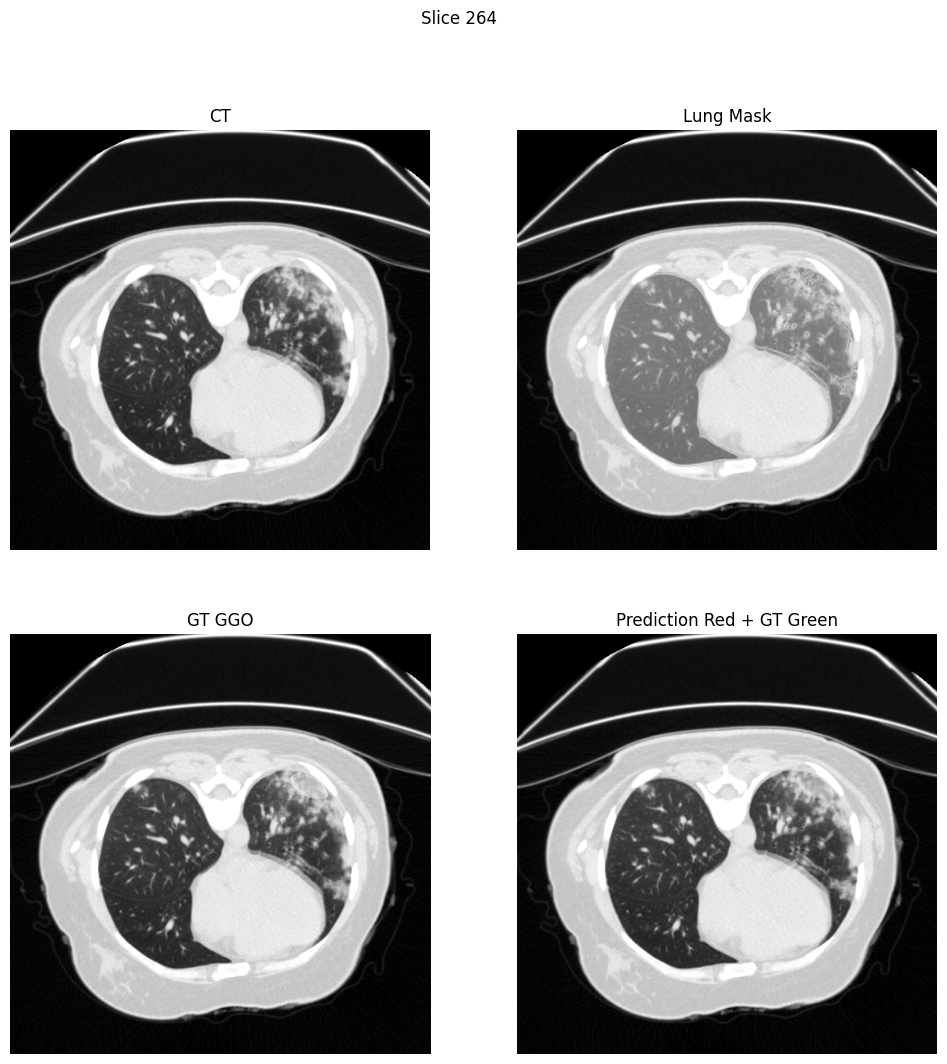

In [18]:
def get_analysis_lung_mask(ct_data, lung_mask, upper_hu=100, dilation_iterations=2):
    expanded = ndimage.binary_dilation(lung_mask, iterations=dilation_iterations)
    analysis_mask = expanded & (ct_data < upper_hu)
    return analysis_mask.astype(bool)


analysis_mask = get_analysis_lung_mask(ct_data, lung_mask, upper_hu=100, dilation_iterations=2)

print('Analysis mask voxels:', int(analysis_mask.sum()))
print('Analysis / CT ratio:', analysis_mask.sum() / ct_data.size)

if gt_mask.sum() > 0:
    gt_inside_analysis = (gt_mask & analysis_mask).sum() / gt_mask.sum()
    print('GT inside analysis mask ratio:', gt_inside_analysis)

show_four_panel(ct_data, gt=gt_mask, lung=analysis_mask)

## 8. HU statistics for GT and lung

In [19]:
def print_hu_stats(values, label):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        print(label, 'is empty')
        return

    print(f'\n{label} HU statistics')
    print('Min :', float(np.min(values)))
    print('P1  :', float(np.percentile(values, 1)))
    print('P5  :', float(np.percentile(values, 5)))
    print('P25 :', float(np.percentile(values, 25)))
    print('P50 :', float(np.percentile(values, 50)))
    print('P75 :', float(np.percentile(values, 75)))
    print('P95 :', float(np.percentile(values, 95)))
    print('P99 :', float(np.percentile(values, 99)))
    print('Max :', float(np.max(values)))
    print('Mean:', float(np.mean(values)))
    print('Std :', float(np.std(values)))


gt_values = ct_data[gt_mask]
lung_values = ct_data[lung_mask]
analysis_values = ct_data[analysis_mask]

print_hu_stats(gt_values, 'GT GGO')
print_hu_stats(lung_values, 'Strict lung mask')
print_hu_stats(analysis_values, 'Analysis lung mask')


GT GGO HU statistics
Min : -802.0
P1  : -745.0
P5  : -675.0
P25 : -521.0
P50 : -387.0
P75 : -259.0
P95 : -109.0
P99 : -42.0
Max : 201.0
Mean: -390.41891833470237
Std : 173.6312262195012

Strict lung mask HU statistics
Min : -1024.0
P1  : -864.0
P5  : -841.0
P25 : -801.0
P50 : -757.0
P75 : -694.0
P95 : -492.0
P99 : -355.0
Max : 45.0
Mean: -728.1524122795487
Std : 108.42618392022695

Analysis lung mask HU statistics
Min : -1024.0
P1  : -863.0
P5  : -839.0
P25 : -797.0
P50 : -747.0
P75 : -654.0
P95 : -198.0
P99 : -38.0
Max : 99.0
Mean: -678.5970220266446
Std : 189.82566827129017


## 9. HU histogram comparison

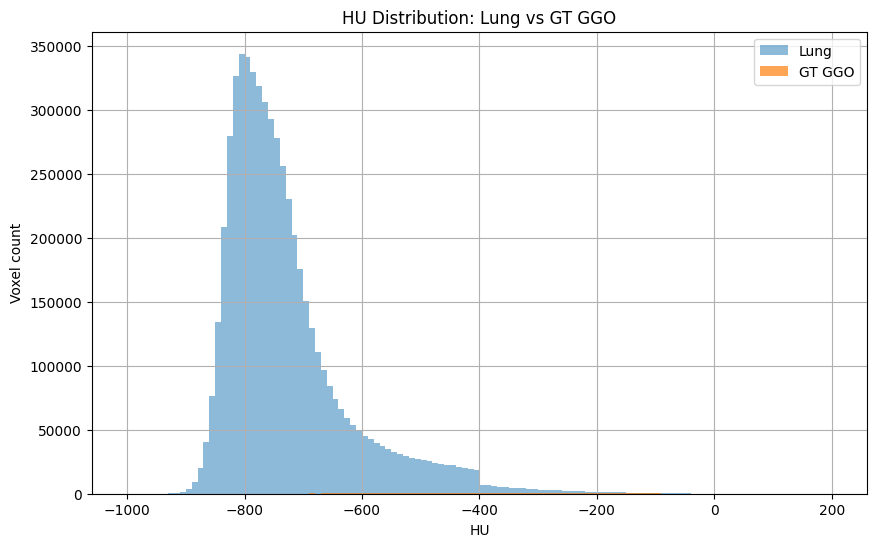

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(lung_values, bins=120, range=(-1000, 200), alpha=0.5, label='Lung')
plt.hist(gt_values, bins=120, range=(-1000, 200), alpha=0.7, label='GT GGO')
plt.xlabel('HU')
plt.ylabel('Voxel count')
plt.title('HU Distribution: Lung vs GT GGO')
plt.legend()
plt.grid(True)
plt.show()

## 10. Run current detector

Min component voxels: 1305
Pred voxels: 0
Dice=0.0000, IoU=0.0000, Sensitivity=0.0000, Precision=0.0000


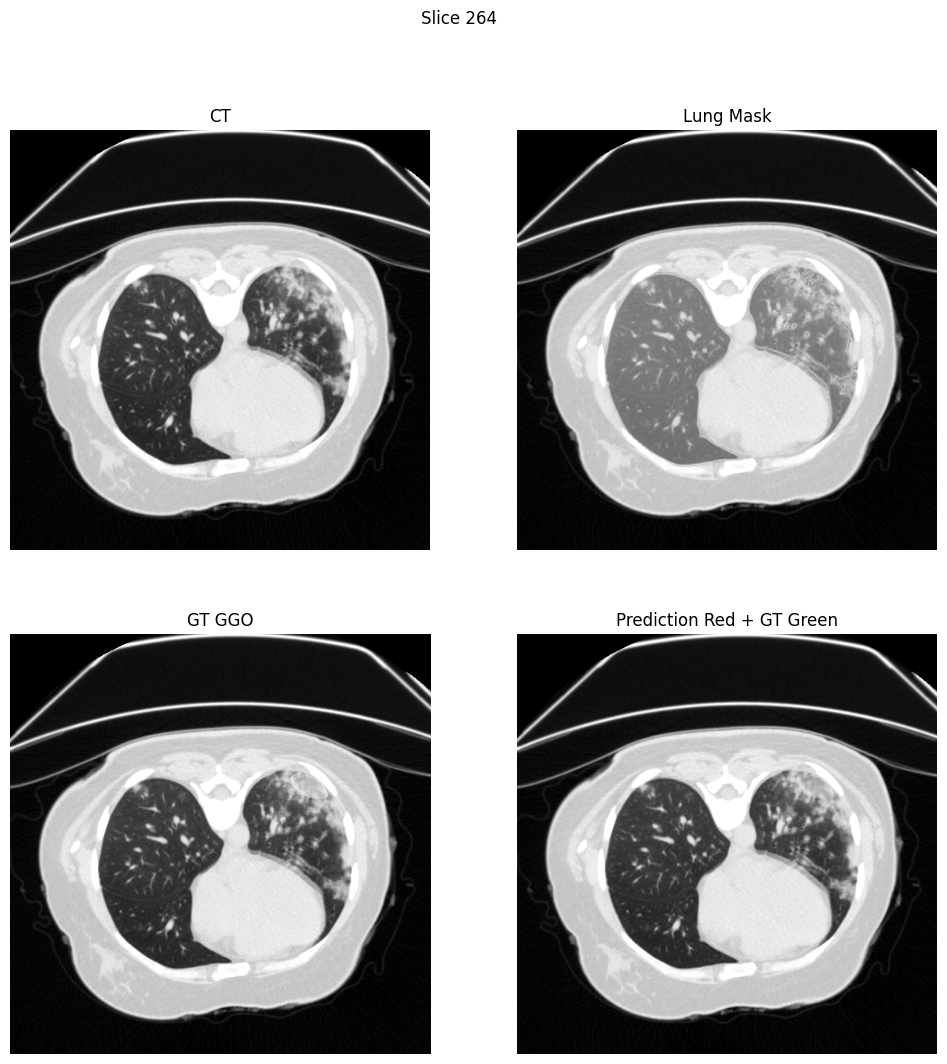

In [21]:
LOWER_HU = -700
UPPER_HU = -250
SMOOTHING_SIGMA_MM = 1.5
ADAPTIVE_PERCENTILE = 92
MIN_LESION_VOLUME_MM3 = 500.0

min_component_voxels = min_volume_to_voxels(MIN_LESION_VOLUME_MM3, spacing=spacing)
print('Min component voxels:', min_component_voxels)

pred_mask = detect_ggo(
    ct_data,
    analysis_mask,
    spacing=spacing,
    lower_hu=LOWER_HU,
    upper_hu=UPPER_HU,
    min_size=min_component_voxels,
    smoothing_sigma_mm=SMOOTHING_SIGMA_MM,
    adaptive_percentile=ADAPTIVE_PERCENTILE,
)

dice = compute_dice(pred_mask, gt_mask)
iou = compute_iou(pred_mask, gt_mask)
sens, prec = compute_sensitivity_precision(pred_mask, gt_mask)

print('Pred voxels:', int(pred_mask.sum()))
print(f'Dice={dice:.4f}, IoU={iou:.4f}, Sensitivity={sens:.4f}, Precision={prec:.4f}')

show_four_panel(ct_data, gt=gt_mask, pred=pred_mask, lung=analysis_mask)

## 11. Validate adaptive threshold

In [22]:
sigma_voxels = spacing_to_sigma_voxels(spacing, SMOOTHING_SIGMA_MM)
smoothed_ct = ndimage.gaussian_filter(ct_data, sigma=sigma_voxels)

adaptive_lower = get_case_adaptive_threshold(
    smoothed_ct,
    analysis_mask,
    percentile=ADAPTIVE_PERCENTILE,
    lower_bound=LOWER_HU,
    upper_bound=UPPER_HU,
)

print('Sigma voxels:', sigma_voxels)
print('Adaptive lower HU:', adaptive_lower)
print('Upper HU:', UPPER_HU)

Sigma voxels: (2.098360655737705, 2.098360655737705, 2.0)
Adaptive lower HU: -350.38711348911386
Upper HU: -250


## 12. Threshold and parameter sweep for one case

In [23]:
parameter_sets = []

for percentile in [80, 85, 88, 90, 92, 95]:
    for sigma in [0.75, 1.0, 1.5]:
        for min_volume in [50, 100, 300, 500]:
            parameter_sets.append({
                'lower_hu': -750,
                'upper_hu': -250,
                'percentile': percentile,
                'sigma_mm': sigma,
                'min_volume_mm3': min_volume,
            })

results = []

for params in parameter_sets:
    min_vox = min_volume_to_voxels(params['min_volume_mm3'], spacing=spacing)
    pred = detect_ggo(
        ct_data,
        analysis_mask,
        spacing=spacing,
        lower_hu=params['lower_hu'],
        upper_hu=params['upper_hu'],
        min_size=min_vox,
        smoothing_sigma_mm=params['sigma_mm'],
        adaptive_percentile=params['percentile'],
    )
    d = compute_dice(pred, gt_mask)
    i = compute_iou(pred, gt_mask)
    s, p = compute_sensitivity_precision(pred, gt_mask)
    results.append({
        **params,
        'min_voxels': min_vox,
        'dice': d,
        'iou': i,
        'sensitivity': s,
        'precision': p,
        'pred_voxels': int(pred.sum()),
    })

results_sorted = sorted(results, key=lambda x: x['dice'], reverse=True)
results_sorted[:10]

[{'lower_hu': -750,
  'upper_hu': -250,
  'percentile': 90,
  'sigma_mm': 1.5,
  'min_volume_mm3': 500,
  'min_voxels': 1305,
  'dice': np.float64(0.1951252661622797),
  'iou': np.float64(0.10811014332689073),
  'sensitivity': np.float64(0.1862003372097245),
  'precision': np.float64(0.2049488460622389),
  'pred_voxels': 21015},
 {'lower_hu': -750,
  'upper_hu': -250,
  'percentile': 90,
  'sigma_mm': 1.0,
  'min_volume_mm3': 500,
  'min_voxels': 1305,
  'dice': np.float64(0.19471924202312943),
  'iou': np.float64(0.10786091922973025),
  'sensitivity': np.float64(0.12083351346672394),
  'precision': np.float64(0.5011655011646026),
  'pred_voxels': 5577},
 {'lower_hu': -750,
  'upper_hu': -250,
  'percentile': 90,
  'sigma_mm': 1.0,
  'min_volume_mm3': 300,
  'min_voxels': 783,
  'dice': np.float64(0.18955001355380863),
  'iou': np.float64(0.10469773535466965),
  'sensitivity': np.float64(0.12091997751929405),
  'precision': np.float64(0.43833254975640445),
  'pred_voxels': 6381},
 {'lo

## 13. Convert sweep results to table

,lower_hu,upper_hu,percentile,sigma_mm,min_volume_mm3,min_voxels,dice,iou,sensitivity,precision,pred_voxels
0,-750,-250,90,1.50,500,1305,0.195125,0.108110,0.186200,0.204949,21015
1,-750,-250,90,1.00,500,1305,0.194719,0.107861,0.120834,0.501166,5577
2,-750,-250,90,1.00,300,783,0.189550,0.104698,0.120920,0.438333,6381
3,-750,-250,90,1.00,100,261,0.180873,0.099428,0.125546,0.323385,8980
4,-750,-250,88,0.75,300,783,0.179558,0.098635,0.277939,0.132617,48478
5,-750,-250,88,0.75,500,1305,0.179558,0.098635,0.277939,0.132617,48478
6,-750,-250,90,1.50,300,783,0.177468,0.097374,0.187108,0.168772,25644
7,-750,-250,90,1.00,50,130,0.165100,0.089977,0.127924,0.232736,12714
8,-750,-250,88,0.75,100,261,0.161570,0.087885,0.278328,0.113822,56562
9,-750,-250,88,1.00,500,1305,0.156738,0.085033,0.302581,0.105762,66177


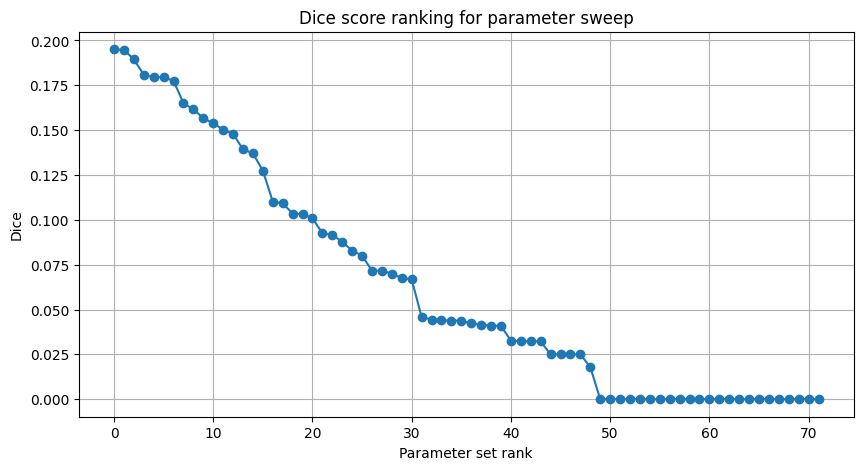

In [24]:
import pandas as pd

df = pd.DataFrame(results_sorted)
display(df.head(15))

plt.figure(figsize=(10, 5))
plt.plot(range(len(df)), df['dice'].values, marker='o')
plt.xlabel('Parameter set rank')
plt.ylabel('Dice')
plt.title('Dice score ranking for parameter sweep')
plt.grid(True)
plt.show()

## 14. Visualize best parameter result

Best parameter set:
{'lower_hu': -750, 'upper_hu': -250, 'percentile': 90, 'sigma_mm': 1.5, 'min_volume_mm3': 500, 'min_voxels': 1305, 'dice': np.float64(0.1951252661622797), 'iou': np.float64(0.10811014332689073), 'sensitivity': np.float64(0.1862003372097245), 'precision': np.float64(0.2049488460622389), 'pred_voxels': 21015}


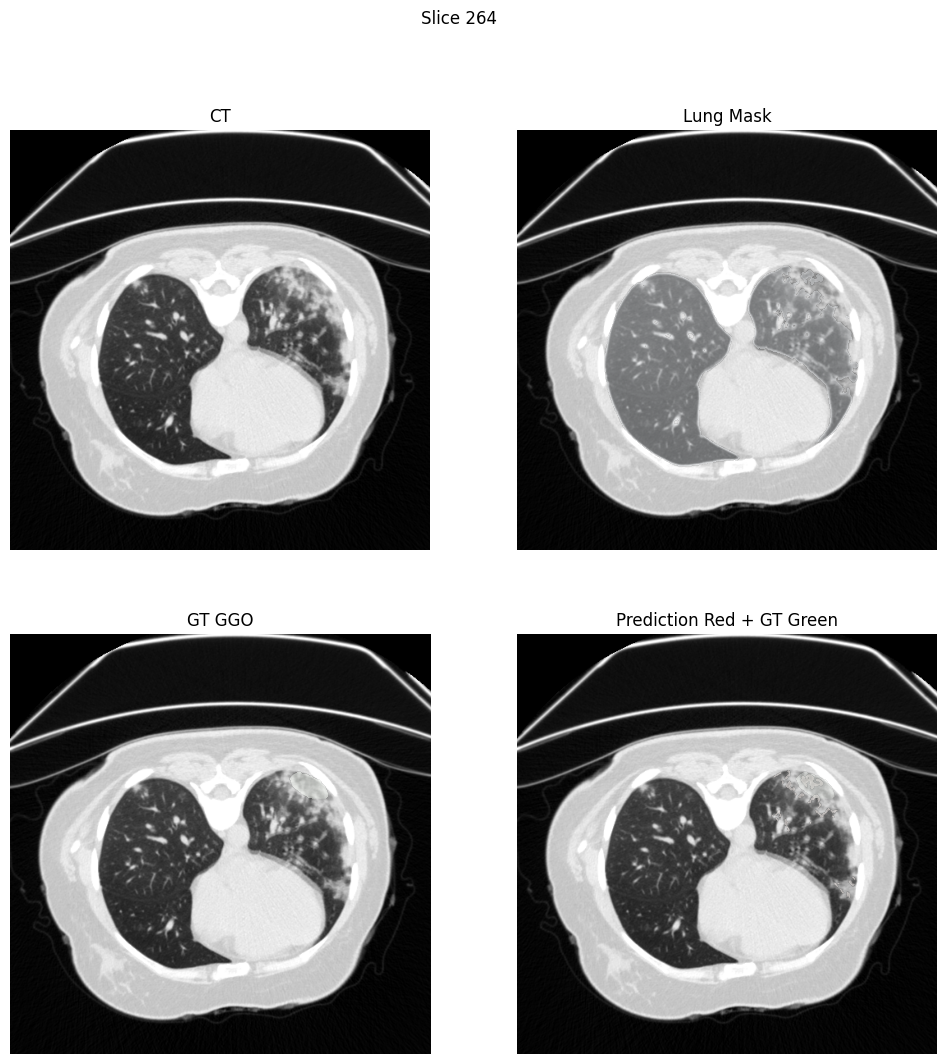

In [25]:
best = results_sorted[0]
print('Best parameter set:')
print(best)

best_min_vox = min_volume_to_voxels(best['min_volume_mm3'], spacing=spacing)
best_pred = detect_ggo(
    ct_data,
    analysis_mask,
    spacing=spacing,
    lower_hu=best['lower_hu'],
    upper_hu=best['upper_hu'],
    min_size=best_min_vox,
    smoothing_sigma_mm=best['sigma_mm'],
    adaptive_percentile=best['percentile'],
)

show_four_panel(ct_data, gt=gt_mask, pred=best_pred, lung=analysis_mask)

## 15. Simple vessel suppression experiment

This removes very dense vessel-like regions from the prediction. Use carefully because true GGO near vessels may also be removed.

After vessel suppression
Pred voxels: 7775
Dice=0.1418, IoU=0.0763, Sensitivity=0.0947, Precision=0.2818


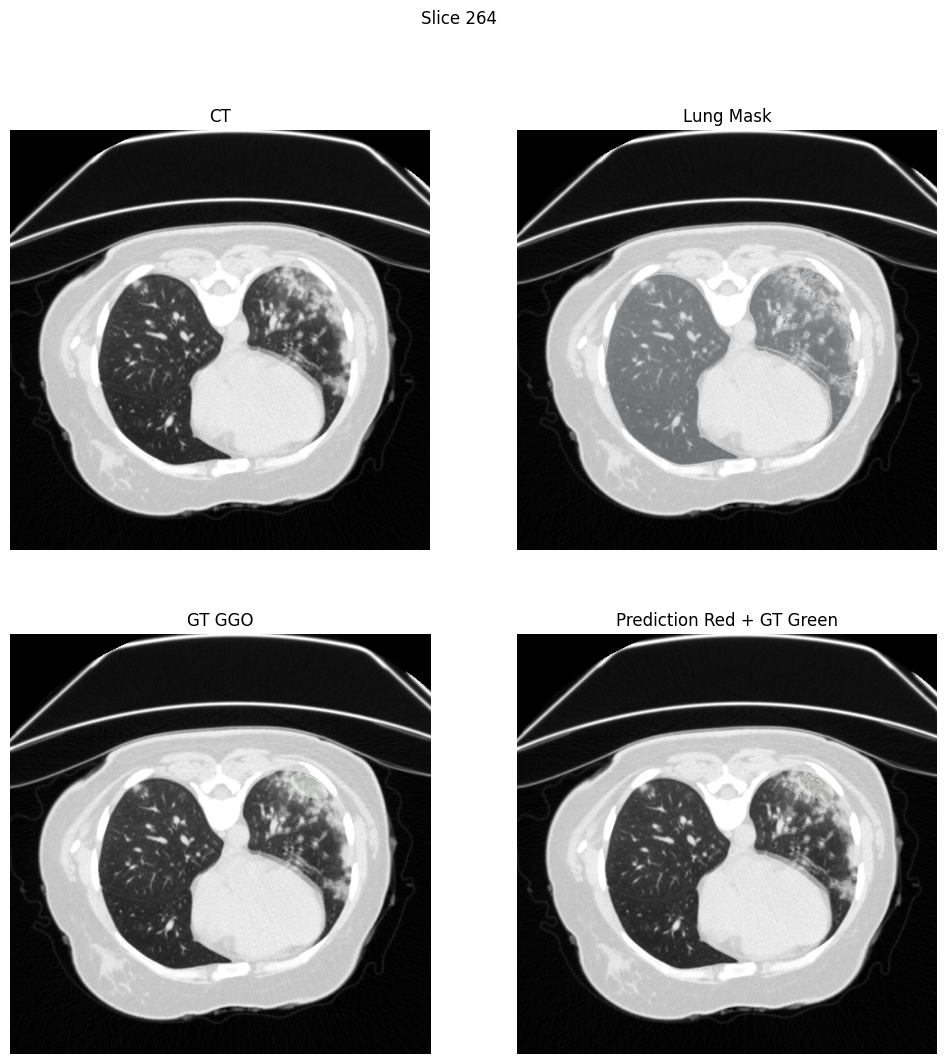

In [26]:
def suppress_vessels_by_hu(pred_mask, ct_data, vessel_hu=-300, dilation_iterations=1):
    vessel_mask = ct_data > vessel_hu
    vessel_mask = ndimage.binary_dilation(vessel_mask, iterations=dilation_iterations)
    cleaned = pred_mask & ~vessel_mask
    return cleaned.astype(bool)


vessel_cleaned = suppress_vessels_by_hu(best_pred, ct_data, vessel_hu=-300, dilation_iterations=1)

d = compute_dice(vessel_cleaned, gt_mask)
i = compute_iou(vessel_cleaned, gt_mask)
s, p = compute_sensitivity_precision(vessel_cleaned, gt_mask)

print('After vessel suppression')
print('Pred voxels:', int(vessel_cleaned.sum()))
print(f'Dice={d:.4f}, IoU={i:.4f}, Sensitivity={s:.4f}, Precision={p:.4f}')

show_four_panel(ct_data, gt=gt_mask, pred=vessel_cleaned, lung=analysis_mask)

## 16. Validate multiple cases without viewer

This helps you see whether the selected parameters work across several cases, not only one case.

In [27]:
def evaluate_sample(sample, params):
    ct, _, header = load_nifti_file(sample['ct_path'])
    gt, _, _ = load_ggo_gt_mask(sample['seg_path'], sample['ggo_channels'])
    sp = get_voxel_spacing(header)
    lung = get_lung_mask(ct, lung_threshold=-400)
    analysis = get_analysis_lung_mask(ct, lung, upper_hu=100, dilation_iterations=2)
    min_vox = min_volume_to_voxels(params['min_volume_mm3'], spacing=sp)
    pred = detect_ggo(
        ct,
        analysis,
        spacing=sp,
        lower_hu=params['lower_hu'],
        upper_hu=params['upper_hu'],
        min_size=min_vox,
        smoothing_sigma_mm=params['sigma_mm'],
        adaptive_percentile=params['percentile'],
    )
    d = compute_dice(pred, gt)
    i = compute_iou(pred, gt)
    s, p = compute_sensitivity_precision(pred, gt)
    return {
        'name': sample['name'],
        'dice': d,
        'iou': i,
        'sensitivity': s,
        'precision': p,
        'gt_voxels': int(gt.sum()),
        'pred_voxels': int(pred.sum()),
        'gt_inside_analysis': float((gt & analysis).sum() / max(gt.sum(), 1)),
    }


MULTI_CASES = min(5, len(samples))
multi_results = []

for idx in range(MULTI_CASES):
    print('Evaluating', idx, samples[idx]['name'])
    multi_results.append(evaluate_sample(samples[idx], best))

multi_df = pd.DataFrame(multi_results)
display(multi_df)
print('\nMean metrics:')
display(multi_df[['dice', 'iou', 'sensitivity', 'precision']].mean())

Evaluating 0 train_67_a_2.nii.gz
Evaluating 1 train_20_a_2.nii.gz
Evaluating 2 train_33_a_1.nii.gz
Evaluating 3 train_244_b_1.nii.gz
Evaluating 4 train_298_a_2.nii.gz


,name,dice,iou,sensitivity,precision,gt_voxels,pred_voxels,gt_inside_analysis
0,train_67_a_2.nii.gz,0.195125,0.108110,0.18620,0.204949,23131,21015,0.678743
1,train_20_a_2.nii.gz,0.000000,0.000000,0.00000,0.000000,293909,0,0.000000
2,train_33_a_1.nii.gz,0.000000,0.000000,0.00000,0.000000,890062,0,0.819042
3,train_244_b_1.nii.gz,0.000000,0.000000,0.00000,0.000000,1514,0,1.000000
4,train_298_a_2.nii.gz,0.007092,0.003559,0.00909,0.005814,35643,55729,0.787504



Mean metrics:


dice           0.040443
iou            0.022334
sensitivity    0.039058
precision      0.042153
dtype: float64

## 17. Notes for deciding final pipeline parameters

- If `GT inside lung mask ratio` is low, improve lung segmentation before tuning GGO thresholds.
- If prediction is zero, adaptive percentile or minimum lesion volume is too strict.
- If prediction is huge, adaptive percentile is too low or HU range is too broad.
- If precision is low, add vessel/bronchial suppression or stronger component filtering.
- If sensitivity is low, reduce percentile, reduce minimum lesion volume, or expand the analysis mask.
- Do not choose best parameters per case for final evaluation. Use the notebook only to select one fixed parameter set, then evaluate all cases with that fixed setting.